# Simple orthogonal model

In [29]:
include("framework.jl")
include("models_registry.jl")

In [56]:
# --- 1. Build the atomistic system ---
# Honeycomb lattice (graphene-like), 2-atom basis (A, B sublattices).
# Lattice vectors chosen so nearest-neighbor A-B distance = d0 = 1.0 Å
# to match the hopping rule in orthogonal_sk_params.toml.

d_nn = 1.0                    # nearest-neighbor A-B distance (Angstrom)
a = d_nn * sqrt(3)            # honeycomb lattice constant

lattice_vectors = [ a*sqrt(3)/2   a*sqrt(3)/2   0.0;
                     a/2          -a/2          0.0;
                     0.0           0.0          20.0 ]   # large vacuum in z

lattice = Lattice(lattice_vectors)
system = System(lattice)

add_atom!(system, :A, [0.0, 0.0, 0.0], ["s"])
add_atom!(system, :B, [d_nn, 0.0, 0.0], ["s"])

System(Lattice([1.4999999999999998 1.4999999999999998 0.0; 0.8660254037844386 -0.8660254037844386 0.0; 0.0 0.0 20.0]), Atom[Atom(:A, [0.0, 0.0, 0.0], ["s"]), Atom(:B, [1.0, 0.0, 0.0], ["s"])])

In [ ]:
# --- 2. Load the model (framework dispatches to the model layer) ---
model = load_etb(system, "orthogonal_sk", "parameters/simple_model/orthogonal_sk_params.toml")
show_params(model)

=== Orthogonal SK Model Parameters ===
Onsite energies:
  species=:A orbital=s => 0.0 eV
  species=:B orbital=s => 1.0 eV
Hopping rules (cutoff = 1.1 Å):
  :B.s <-> :B.s : t0=-2.0, d0=1.0, beta=0.0
  :A.s <-> :B.s : t0=-2.0, d0=1.0, beta=0.0
  :A.s <-> :A.s : t0=-1.0, d0=1.0, beta=0.0


In [59]:
# --- 3. Define a k-path and compute the band structure ---
b1 = [2*pi/(a*sqrt(3)),  2*pi/a, 0.0]
b2 = [2*pi/(a*sqrt(3)), -2*pi/a, 0.0]

Gamma = [0.0, 0.0, 0.0]
M     = 0.5 .* (b1 .+ b2)
K     = (2/3) .* b1 .+ (1/3) .* b2

k_path = [Gamma, M, K, Gamma]
n_points = 300

k_distances, bands = band_structure(model, k_path, n_points)

# tick positions at each high-symmetry point along the path
seg_points = n_points ÷ (length(k_path) - 1)
tick_idxs = [1 + (i-1)*seg_points for i in 1:length(k_path)-1]
push!(tick_idxs, length(k_distances))
xticks = k_distances[tick_idxs]
xticklabels = ["Γ", "M", "K", "Γ"]

4-element Vector{String}:
 "Γ"
 "M"
 "K"
 "Γ"

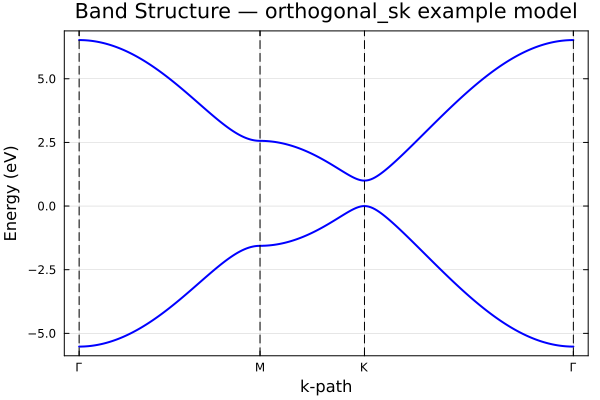

Done. Plot saved to bands_example.png


In [60]:
# --- 4. Plot ---
p = plot_bands(k_distances, bands; xticks=xticks, xticklabels=xticklabels,
               title="Band Structure — orthogonal_sk example model")
display(p)
savefig(p, "bands_example.png")

println("Done. Plot saved to bands_example.png")

# Jancu1998 model

In [68]:
include("framework.jl")
include("models_registry.jl")

In [42]:
a = 5.6
a1 = [a/2, 0.0, a/2]
a2 = [a/2, a/2, 0.0]
a3 = [0.0, a/2, a/2]   # large vacuum in z

lattice = Lattice(a1,a2,a3)
system = System(lattice)

add_atom!(system, :Si, [0.0, 0.0, 0.0])
add_atom!(system, :Si, [a/4, a/4, a/4])

System(Lattice([2.8, 0.0, 2.8], [2.8, 2.8, 0.0], [0.0, 2.8, 2.8]), Atom[Atom(:Si, [0.0, 0.0, 0.0]), Atom(:Si, [1.4, 1.4, 1.4])], 3)

In [71]:
# new way, using templates
#system = make_sc(5.6, :Al)
system = make_diamond(5.0, :C)
#system = make_graphene(1.0, :C)

System(Lattice([0.0, 2.5, 2.5], [2.5, 0.0, 2.5], [2.5, 2.5, 0.0]), Atom[Atom(:C, [0.0, 0.0, 0.0]), Atom(:C, [1.25, 1.25, 1.25])], 3)

In [46]:
reciprocal_lattice(system)

([6.283185307179586, -3.627598728468436, 0.0], [0.0, 7.255197456936872, 0.0], nothing)

In [72]:
plot_unitcell(system, repetitions=(3,3,3))

In [9]:
model = load_etb(system, "jancu1998", "parameters/jancu1998/jancu1998_AlP.toml")
show_params(model)

=== Jancu 1998 spds* Model Parameters ===
Lattice constant a = 5.4635 Å, cutoff = 2.7 Å
Onsite (a): Es=-5.3355 Ep=3.3471 Ed=14.1717 Es*=20.5963 Δ/3=0.0196
Onsite (c): Es=0.9573 Ep=6.3392 Ed=14.1717 Es*=20.5963 Δ/3=0.0073
Two-center integrals (a->c):
  sss = -1.7403
  sps = 2.6146
  pss = 2.7804
  sSss = -1.6448
  sssS = -1.4307
  sSsSs = -3.6444
  sSps = 2.0632
  psSs = 2.3361
  pps = 4.0355
  ppp = -1.3077
  sds = -2.5253
  dss = -2.1687
  sSds = -0.781
  dsSs = -0.7211
  pds = -1.675
  dps = -1.8239
  pdp = 1.876
  dpp = 2.1848
  dds = -1.3479
  ddp = 2.375
  ddd = -1.8464
Number of nearest-neighbor bonds: 4


In [10]:
Γ = [0.0, 0.0, 0.0]
L = [0.5, 0.5, 0.5]
K = [0.5, 0.5, 0.0]
X = [0.0, 0.5, 0.0]

k_path = [K, L, Γ, X]
n_points = 100

k_distances, bands = band_structure(model, k_path, n_points)

# tick positions at each high-symmetry point along the path
seg_points = n_points ÷ (length(k_path) - 1)
tick_idxs = [1 + (i-1)*seg_points for i in 1:length(k_path)-1]
push!(tick_idxs, length(k_distances))
xticks = k_distances[tick_idxs]
xticklabels = ["K", "L", "Γ", "X"]

4-element Vector{String}:
 "K"
 "L"
 "Γ"
 "X"

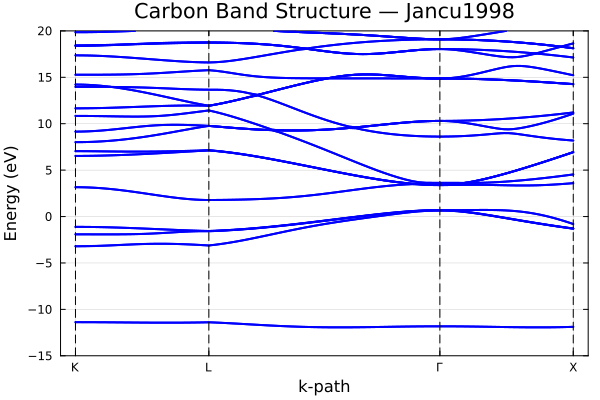

In [11]:
p = plot_bands(k_distances, bands; xticks=xticks, xticklabels=xticklabels,
               title="Carbon Band Structure — Jancu1998")
p = plot(p; ylims=(-15,20))
display(p)
#savefig(p, "bands_example.png")

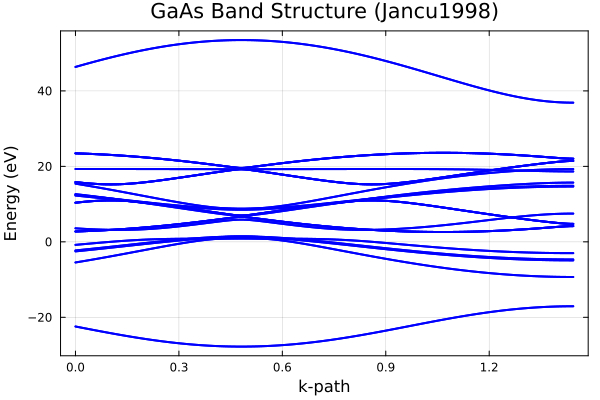

In [5]:
include("framework.jl")
include("models_registry.jl")
include("models/jancu1998_model.jl")

sys = make_zincblende(5.6532, :Ga, :As)
model = Jancu1998Model(sys, "models/jancu1998.toml"; soc=true)

b1, b2, b3 = reciprocal_lattice(sys)
G = [0.0, 0.0, 0.0]
X = 0.5 .* b1
L = 0.5 .* (b1 .+ b2 .+ b3) ./ 2 .+ 0.5 .* [0.0,0.0,0.0]  # placeholder, adjust as needed
k_path = [L, G, X]

k_dist, bands = band_structure(model, k_path, 200)

using Plots
plot_bands(k_dist, bands, title="GaAs Band Structure (Jancu1998)")

In [1]:
include("framework.jl")
show_models()
load_model(:Jancu1998Model)

Available models:
  :OrthogonalSKModel
  :Jancu1998Model
Model 'Jancu1998Model' loaded successfully.


In [2]:
sys = make_zincblende(5.6532, :Ga, :As)

System(Lattice([0.0, 2.8266, 2.8266], [2.8266, 0.0, 2.8266], [2.8266, 2.8266, 0.0]), Atom[Atom(:Ga, [0.0, 0.0, 0.0]), Atom(:As, [1.4133, 1.4133, 1.4133])], 3)

In [3]:
model = Jancu1998Model(sys)

Jancu1998Model(System(Lattice([0.0, 2.8266, 2.8266], [2.8266, 0.0, 2.8266], [2.8266, 2.8266, 0.0]), Atom[Atom(:Ga, [0.0, 0.0, 0.0]), Atom(:As, [1.4133, 1.4133, 1.4133])], 3), JancuParams(Dict{Tuple{String, String}, JancuPair}(("C", "C") => JancuPair("C", "C", 3.5668, 1.5444697051091678, 2.7, JancuOnsite("C", ["s", "e", "px", "py", "pz", "dxy", "dyz", "dzx", "dx2-y2", "dz2"], Dict("pz" => 7.085, "dz2" => 27.9267, "e" => 38.2661, "px" => 7.085, "dyz" => 27.9267, "py" => 7.085, "dxy" => 27.9267, "s" => -1.0458, "dx2-y2" => 27.9267, "dzx" => 27.9267…), 0.0), JancuOnsite("C", ["s", "e", "px", "py", "pz", "dxy", "dyz", "dzx", "dx2-y2", "dz2"], Dict("pz" => 7.085, "dz2" => 27.9267, "e" => 38.2661, "px" => 7.085, "dyz" => 27.9267, "py" => 7.085, "dxy" => 27.9267, "s" => -1.0458, "dx2-y2" => 27.9267, "dzx" => 27.9267…), 0.0), Dict{String, JancuHopEntry}("pes" => JancuHopEntry(5.1709, 2.0), "ddp" => JancuHopEntry(4.9779, 2.0), "dds" => JancuHopEntry(-4.1813, 2.0), "eds" => JancuHopEntry(-2.3034,

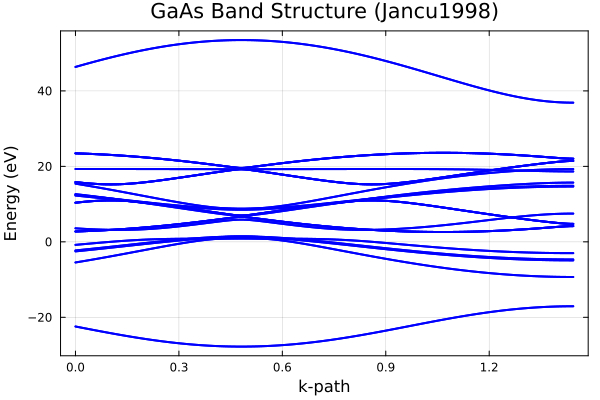

In [4]:
b1, b2, b3 = reciprocal_lattice(sys)
G = [0.0, 0.0, 0.0]
X = 0.5 .* b1
L = 0.5 .* (b1 .+ b2 .+ b3) ./ 2 .+ 0.5 .* [0.0,0.0,0.0]  # placeholder, adjust as needed
k_path = [L, G, X]

k_dist, bands = band_structure(model, k_path, 200)

plot_bands(k_dist, bands, title="GaAs Band Structure (Jancu1998)")